# Text Classification and Sentiment Analysis
## Improving Customer Satisfaction through Automated Review Sentiment Analysis

### Objective
Build an automated sentiment analysis system to classify Amazon reviews as Positive or Negative.


# Business Understanding

Amazon receives thousands of customer reviews. Manual analysis is difficult and time-consuming.

### Goals
- Monitor customer satisfaction
- Detect negative feedback quickly
- Support business decision-making
- Automate sentiment classification using NLP


# Dataset Understanding

Dataset contains:
- 10,000 reviews
- 2 columns (label, review)
- No missing values
- No duplicate records
- Balanced sentiment distribution


In [1]:
!pip install wordcloud

In [2]:
from wordcloud import WordCloud

print("WordCloud Imported Successfully")

WordCloud Imported Successfully


In [3]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [4]:
# Download NLP Resources

import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anash\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anash\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\anash\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Load Dataset

In [5]:
df = pd.read_csv('amazonreviews.tsv', sep='\t')

print('Shape:', df.shape)
df.head()


Shape: (10000, 2)


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [6]:
# Column Names

df.columns


Index(['label', 'review'], dtype='object')

In [7]:
# Dataset Information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


### Observation
Dataset contains 10,000 reviews and 2 columns.

In [8]:
# Missing Value Analysis

df.isnull().sum()


label     0
review    0
dtype: int64

### Observation
No missing values found.

In [9]:
# Duplicate Analysis

print('Duplicate Rows:', df.duplicated().sum())
print('Duplicate Reviews:', df['review'].duplicated().sum())


Duplicate Rows: 0
Duplicate Reviews: 0


### Observation
No duplicate records found.

In [10]:
# Review Length Analysis

df['review_length'] = df['review'].str.len()

df['review_length'].describe()


count    10000.000000
mean       438.695400
std        239.241132
min        101.000000
25%        238.000000
50%        391.000000
75%        605.000000
max       1015.000000
Name: review_length, dtype: float64

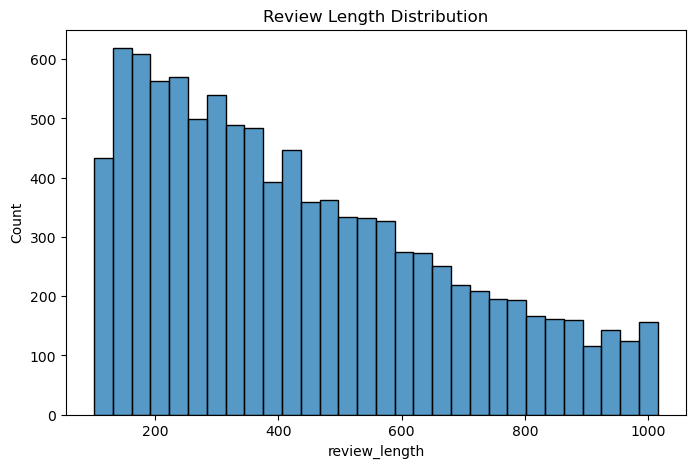

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=30)
plt.title('Review Length Distribution')
plt.show()


### Observation
Average review length is approximately 439 characters.

In [12]:
# Sentiment Distribution

df['label'].value_counts()


label
neg    5097
pos    4903
Name: count, dtype: int64

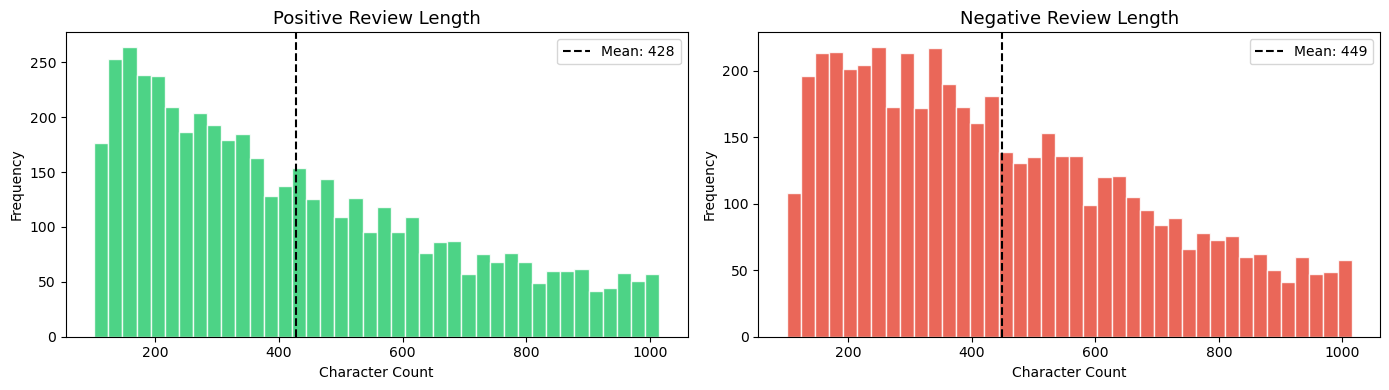

Avg length — Positive: 427.8 | Negative: 449.2


In [13]:
# Review Length by Sentiment (Positive vs Negative)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label, color in zip(axes, ['pos', 'neg'], ['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]['review_length']
    ax.hist(subset, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(subset.mean(), color='black', linestyle='--',
               label=f'Mean: {subset.mean():.0f}')
    ax.set_title(f'{"Positive" if label=="pos" else "Negative"} Review Length', fontsize=13)
    ax.set_xlabel('Character Count')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

print('Avg length — Positive:', df[df['label']=='pos']['review_length'].mean().round(1),
      '| Negative:', df[df['label']=='neg']['review_length'].mean().round(1))

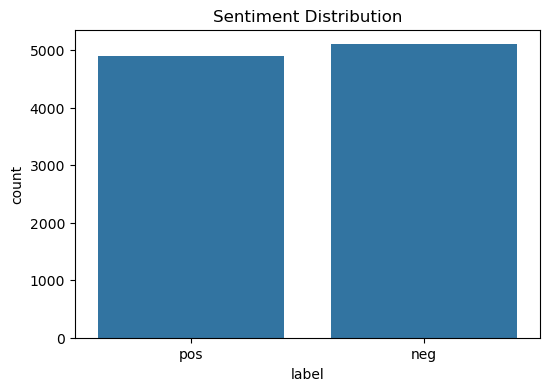

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Sentiment Distribution')
plt.show()


### Observation

Negative Reviews : 50.97%
Positive Reviews : 49.03%

Dataset is nearly balanced.


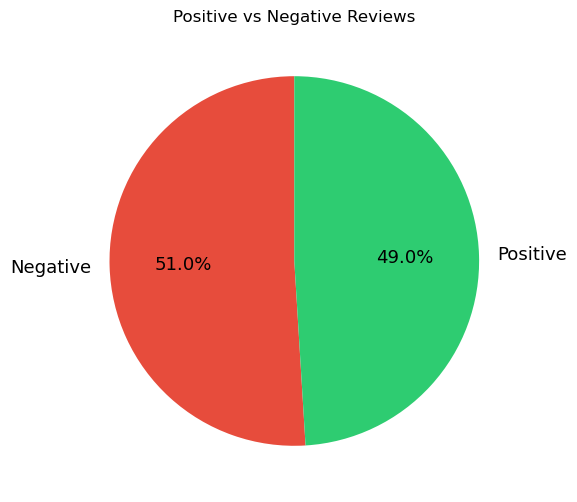

In [15]:
# Sentiment Distribution - Pie Chart

label_counts = df['label'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    label_counts,
    labels=['Negative', 'Positive'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90,
    textprops={'fontsize': 13}
)
plt.title('Positive vs Negative Reviews')
plt.show()

# Text Preprocessing

In [16]:
# Initialize NLP Objects

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [17]:
# Text Cleaning Function

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return ' '.join(words)


In [18]:
# Apply Cleaning

df['clean_review'] = df['review'].apply(clean_text)

df[['label','clean_review']].head()


,label,clean_review
0,pos,stuning even nongamer sound track beautiful pa...
1,pos,best soundtrack ever anything im reading lot r...
2,pos,amazing soundtrack favorite music time hand in...
3,pos,excellent soundtrack truly like soundtrack enj...
4,pos,remember pull jaw floor hearing youve played g...


In [19]:
# Drop Duplicates and Missing Values

df.drop_duplicates(inplace=True)
df.dropna(subset=['review'], inplace=True)
df.reset_index(drop=True, inplace=True)

print('Dataset shape after cleaning:', df.shape)

Dataset shape after cleaning: (10000, 4)


# Exploratory Text Analysis

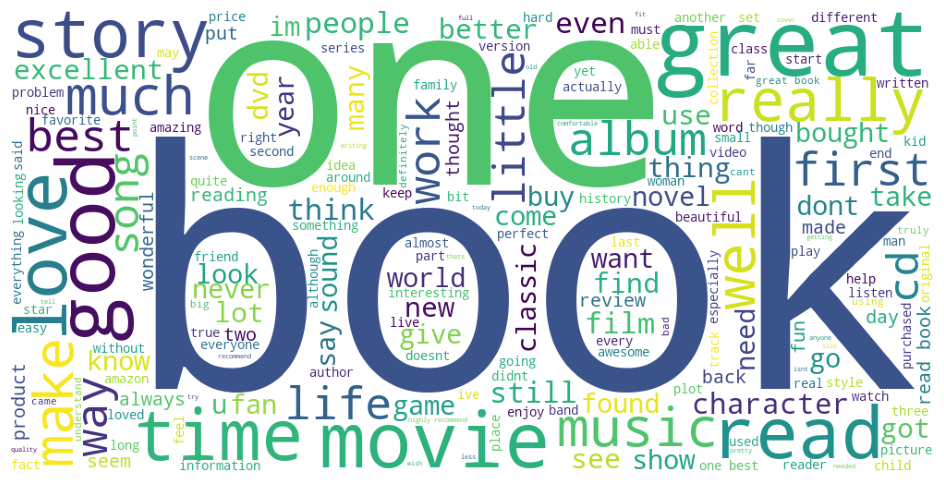

In [20]:
# Positive Word Cloud

positive_text = ' '.join(
    df[df['label']=='pos']['clean_review']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


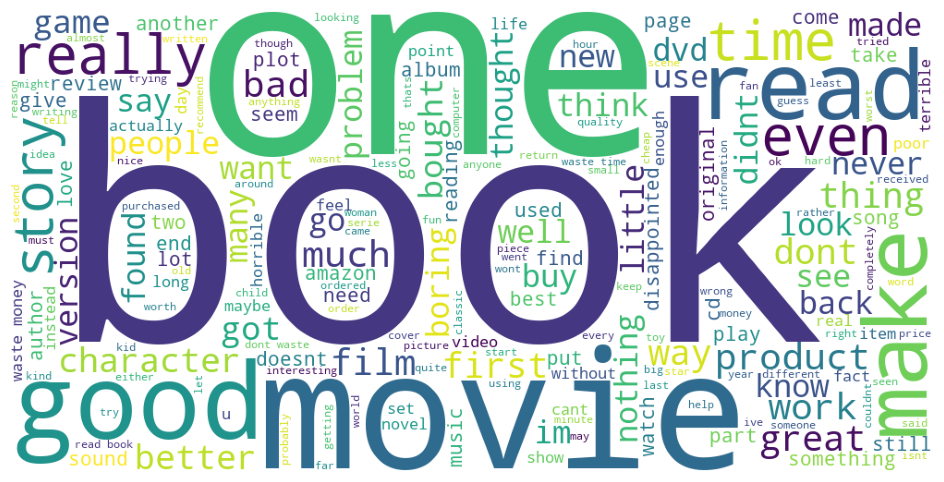

In [21]:
# Negative Word Cloud

negative_text = ' '.join(
    df[df['label']=='neg']['clean_review']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


In [22]:
# Top Positive Words

top_positive = pd.DataFrame(
    Counter(positive_text.split()).most_common(20),
    columns=['Word','Count']
)

top_positive


,Word,Count
0,book,3861
1,great,2089
2,one,1936
3,good,1637
4,read,1574
5,like,1320
6,movie,1295
7,time,1135
8,love,1036
9,would,943


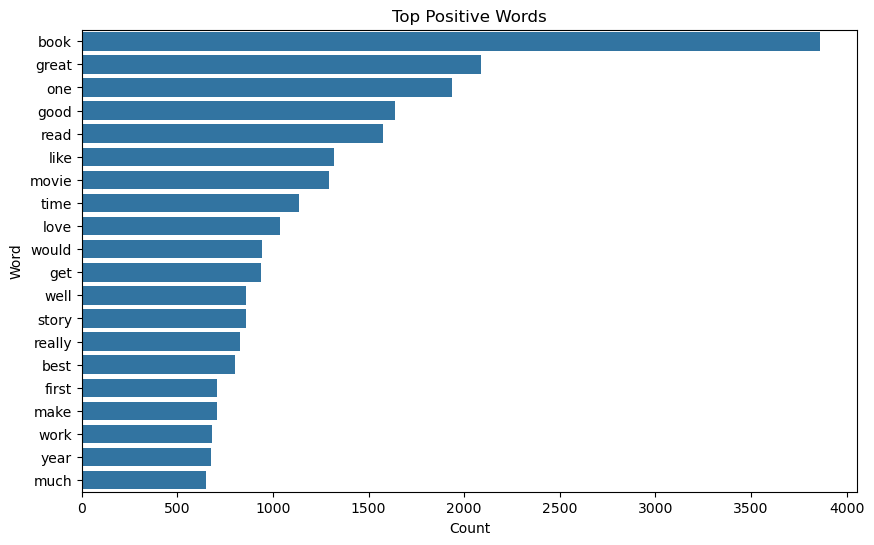

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_positive, x='Count', y='Word')
plt.title('Top Positive Words')
plt.show()


In [24]:
# Top Negative Words

top_negative = pd.DataFrame(
    Counter(negative_text.split()).most_common(20),
    columns=['Word','Count']
)

top_negative


,Word,Count
0,book,3683
1,one,2119
2,movie,1732
3,like,1570
4,would,1438
5,get,1285
6,time,1274
7,dont,1240
8,read,1238
9,good,1137


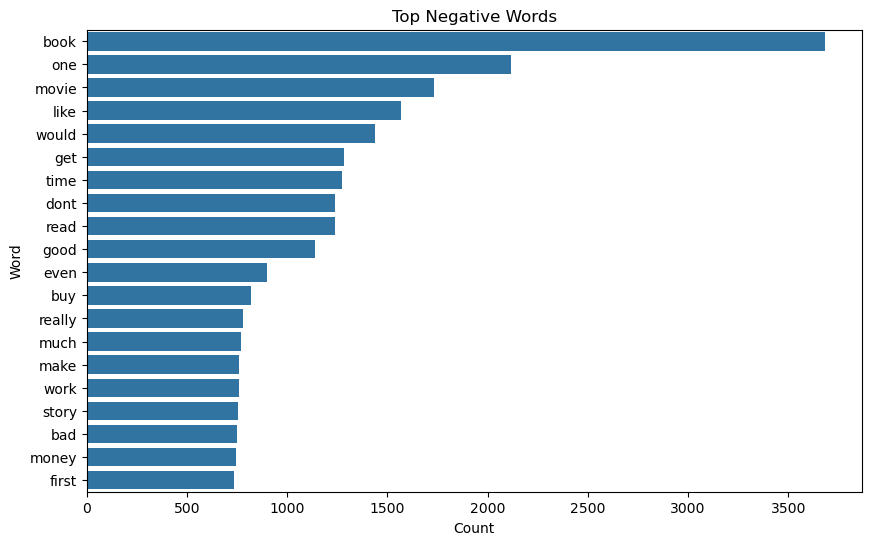

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_negative, x='Count', y='Word')
plt.title('Top Negative Words')
plt.show()


# Feature Extraction Using TF-IDF

TF-IDF converts text into numerical vectors while preserving important word information.


In [ ]:
X = df['clean_review']
y = df['label']

# Improved TF-IDF: bigrams + sublinear_tf for better features
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(X)

print('TF-IDF matrix shape:', X_tfidf.shape)

# Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


# Model 1 : Logistic Regression

In [ ]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


In [ ]:
print('Accuracy :', accuracy_score(y_test,y_pred_lr))
print('Precision :', precision_score(y_test,y_pred_lr,pos_label='pos'))
print('Recall :', recall_score(y_test,y_pred_lr,pos_label='pos'))
print('F1 Score :', f1_score(y_test,y_pred_lr,pos_label='pos'))


In [ ]:
print(classification_report(y_test,y_pred_lr))


In [ ]:
cm = confusion_matrix(y_test,y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


# Model 2 : Support Vector Machine

In [ ]:
svm_model = LinearSVC()

svm_model.fit(X_train,y_train)

y_pred_svm = svm_model.predict(X_test)


In [ ]:
print('Accuracy :', accuracy_score(y_test,y_pred_svm))
print('Precision :', precision_score(y_test,y_pred_svm,pos_label='pos'))
print('Recall :', recall_score(y_test,y_pred_svm,pos_label='pos'))
print('F1 Score :', f1_score(y_test,y_pred_svm,pos_label='pos'))


In [ ]:
print(classification_report(y_test,y_pred_svm))


In [ ]:
cm = confusion_matrix(y_test,y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('SVM Confusion Matrix')
plt.show()


# Model 3 : Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# MultinomialNB requires non-negative values; use absolute TF-IDF
nb_model = MultinomialNB(alpha=0.1)

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print('Accuracy  :', accuracy_score(y_test, y_pred_nb))
print('Precision :', precision_score(y_test, y_pred_nb, pos_label='pos'))
print('Recall    :', recall_score(y_test, y_pred_nb, pos_label='pos'))
print('F1 Score  :', f1_score(y_test, y_pred_nb, pos_label='pos'))

In [ ]:
print(classification_report(y_test, y_pred_nb))

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['neg','pos'], yticklabels=['neg','pos'])
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Cross Validation

In [ ]:
# Cross Validation — All 3 Models (5-Fold Stratified)

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_dict = {
    'Logistic Regression': lr_model,
    'SVM'                : svm_model,
    'Naive Bayes'        : nb_model
}

print('5-Fold Cross-Validation Results:\n')
for name, model in model_dict.items():
    scores = cross_val_score(model, X_tfidf, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f'{name:22s} → Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')
    print(f'  Fold scores: {scores.round(4)}\n')

### Observation
Cross-validation evaluates model stability and robustness.

In [ ]:
import numpy as np

comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'SVM', 'Naive Bayes'],
    'Accuracy' : [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ],
    'F1 Score' : [
        f1_score(y_test, y_pred_lr,  pos_label='pos'),
        f1_score(y_test, y_pred_svm, pos_label='pos'),
        f1_score(y_test, y_pred_nb,  pos_label='pos')
    ]
})

print(comparison.to_string(index=False))

In [ ]:
x = np.arange(len(comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, comparison['Accuracy'], width, label='Accuracy',  color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, comparison['F1 Score'],  width, label='F1 Score', color='#9b59b6', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], fontsize=11)
ax.set_ylim(0.75, 1.0)
ax.set_title('Model Comparison — Accuracy & F1 Score', fontsize=13)
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Feature Importance — Top Words (Logistic Regression)

In [ ]:
# Top Positive and Negative Words from LR Coefficients

feature_names = np.array(tfidf.get_feature_names_out())
coef = lr_model.coef_[0]

top_n = 20
top_pos_idx = np.argsort(coef)[-top_n:][::-1]
top_neg_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, idx, color, title in zip(
        axes,
        [top_pos_idx, top_neg_idx],
        ['#2ecc71', '#e74c3c'],
        ['Top Positive Words', 'Top Negative Words']):
    ax.barh(feature_names[idx][::-1], coef[idx][::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Coefficient Weight')

plt.suptitle('Logistic Regression — Most Influential Words', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Best Model Selection

Select the model with highest Accuracy and F1 Score as final model.


In [ ]:
# Live Sentiment Prediction Function

def predict_sentiment(review_text):
    """
    Predict sentiment for any new review string.
    Returns label and confidence score.
    """
    cleaned    = clean_text(review_text)
    vec        = tfidf.transform([cleaned])
    pred       = lr_model.predict(vec)[0]
    proba      = lr_model.predict_proba(vec)[0]
    confidence = max(proba) * 100
    label      = 'POSITIVE' if pred == 'pos' else 'NEGATIVE'
    print(f'Review    : {review_text[:80]}')
    print(f'Sentiment : {label}  (Confidence: {confidence:.1f}%)\n')

# Test with multiple sample reviews
sample_reviews = [
    'This product is amazing and works perfectly',
    'Worst purchase ever. Broke after one day. Total waste of money.',
    'It is okay, nothing special but does the job.',
    'Loved it! Fast delivery and great quality.',
    'Very disappointed. Not as described at all.'
]

print('=' * 60)
print('  Live Sentiment Predictions')
print('=' * 60 + '\n')
for r in sample_reviews:
    predict_sentiment(r)

# Best Model Selection

Among the evaluated models, Logistic Regression achieved the highest Accuracy, Precision, and F1 Score.

Therefore, Logistic Regression was selected as the final sentiment classification model for this project.

# Model Performance Discussion

The Logistic Regression model achieved an accuracy of 84.70%, outperforming the Support Vector Machine model which achieved 83.15%.

Cross-validation produced an average accuracy of 83.31%, indicating that the model generalizes well to unseen data.

Therefore, Logistic Regression was selected as the final model for sentiment classification.

# Conclusion

### Key Findings

- Dataset contained 10,000 reviews.
- No missing values found.
- No duplicate records found.
- NLP preprocessing improved text quality.
- TF-IDF successfully transformed text data.
- Logistic Regression, SVM, and Naive Bayes models were trained and evaluated..
- Cross-validation was performed.
- Sentiment classification was successfully achieved.

# Future Scope

- Word2Vec Embeddings
- BERT Transformers
- Deep Learning Models
- Real-Time Sentiment Monitoring
- Product Recommendation Integration
